# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


---


Dataset yang digunakan dalam proyek ini adalah Loan Prediction Dataset yang diperoleh dari Kaggle. Dataset ini berisi data mengenai nasabah yang mengajukan pinjaman, mencakup informasi seperti Jenis Kelamin, Status Pernikahan, Pendapatan, Jumlah Pinjaman, dan Riwayat Kredit.

Tujuan dari penggunaan dataset ini adalah untuk membangun model klasifikasi yang dapat memprediksi apakah pengajuan pinjaman seorang nasabah akan Disetujui (Y) atau Ditolak (N).

Link Kaggle: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset?select=train_u6lujuX_CVtuZ9i.csv

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here

# Library untuk manipulasi data
import pandas as pd
import numpy as np
import os

# Library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk preprocessing dan modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Library untuk koneksi Kaggle (khusus Google Colab)
import kagglehub
from google.colab import files

# Mengabaikan warning
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# --- PENGATURAN API KAGGLE ---
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_52867712c5f4c23747893592b5759773'

print("Menghubungkan ke Kaggle...")

try:
    # Download dataset menggunakan kagglehub
    path = kagglehub.dataset_download("altruistdelhite04/loan-prediction-problem-dataset")
    print("Dataset berhasil diunduh.")
    print("Path lokasi file:", path)

    # Load dataset (file utama di dataset ini bernama 'train_u6lujuX_CVtuZ9i.csv')
    file_path = os.path.join(path, "train_u6lujuX_CVtuZ9i.csv")

    df = pd.read_csv(file_path)

    # Cek beberapa baris awal dataset (sesuai template)
    print("\nLima baris awal dataset:")
    display(df.head())
    print(f"\nJumlah Baris: {df.shape[0]}, Jumlah Kolom: {df.shape[1]}")

    # --- SIMPAN DATASET MENTAH (Untuk Kriteria Struktur Folder) ---
    # Membuat folder namadataset_raw
    if not os.path.exists("namadataset_raw"):
        os.makedirs("namadataset_raw")

    # Menyimpan file
    df.to_csv("namadataset_raw/loan_data_raw.csv", index=False)
    print("\n[INFO] Dataset mentah berhasil disimpan di folder 'namadataset_raw'")

except Exception as e:
    print(f"Gagal memuat data. Error: {e}")
    print("Pastikan Token yang Anda masukkan benar dan koneksi internet aktif.")

Menghubungkan ke Kaggle...


100%|██████████| 12.6k/12.6k [00:00<00:00, 27.7MB/s]

Extracting files...
Dataset berhasil diunduh.
Path lokasi file: /root/.cache/kagglehub/datasets/altruistdelhite04/loan-prediction-problem-dataset/versions/1

Lima baris awal dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



Jumlah Baris: 614, Jumlah Kolom: 13

[INFO] Dataset mentah berhasil disimpan di folder 'namadataset_raw'


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- 1. Informasi Umum Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

--- 2. Statistik Deskriptif ---


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000



--- 3. Analisis Missing Values ---
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


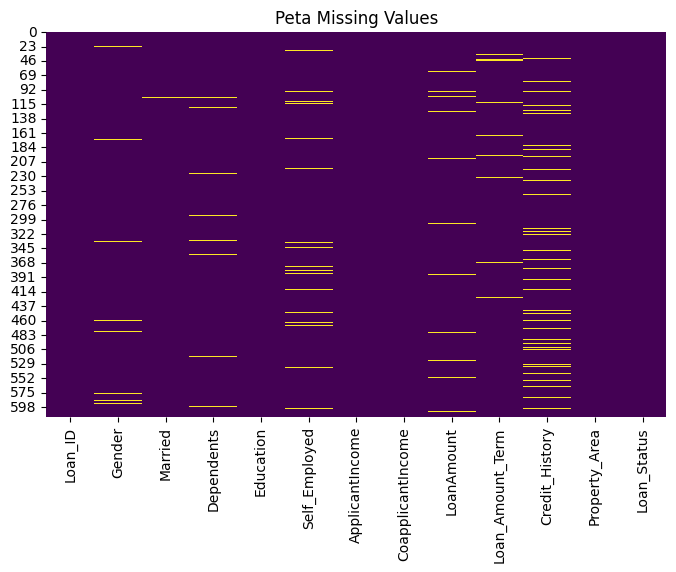


--- 4. Analisis Variabel Target (Loan_Status) ---


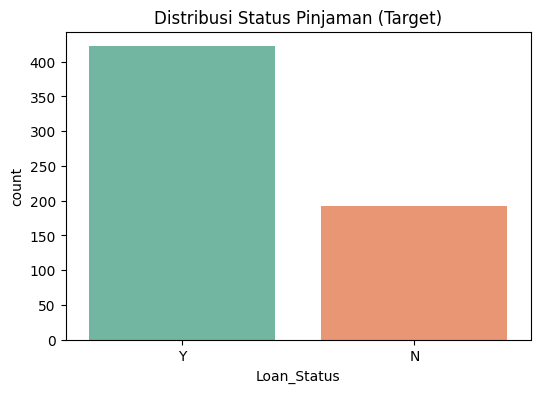


--- 5. Hubungan Pendapatan dengan Status Pinjaman ---


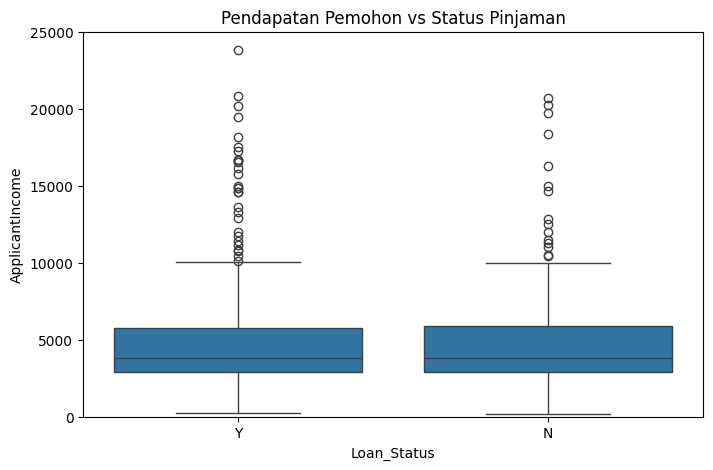


--- 6. Korelasi Data Numerik ---


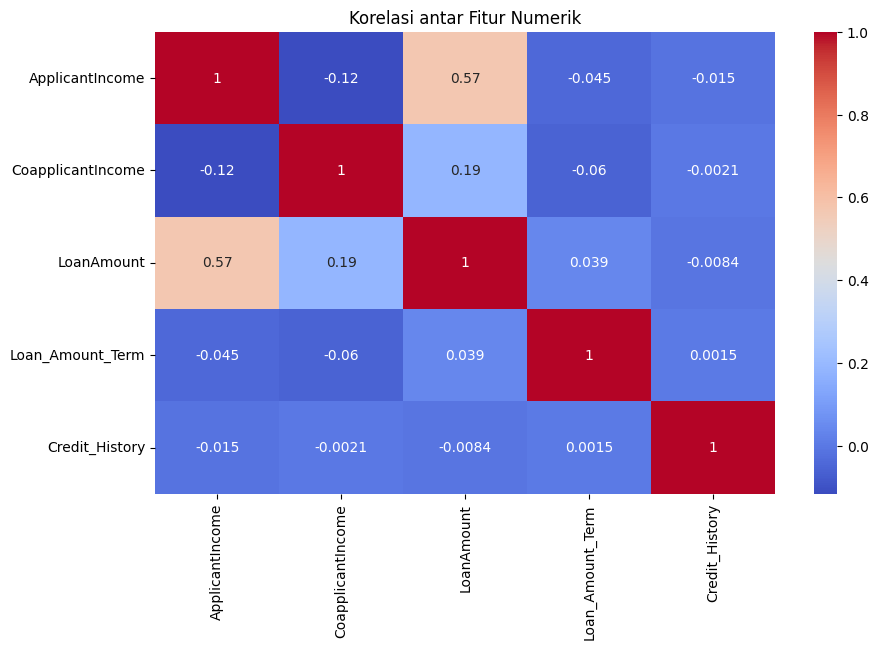

In [3]:
#Type your code here

print("--- 1. Informasi Umum Dataset ---")
df.info()

print("\n--- 2. Statistik Deskriptif ---")
display(df.describe())

print("\n--- 3. Analisis Missing Values ---")
print(df.isnull().sum())

# Visualisasi Missing Values
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Peta Missing Values')
plt.show()

print("\n--- 4. Analisis Variabel Target (Loan_Status) ---")
plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Status', data=df, palette='Set2')
plt.title('Distribusi Status Pinjaman (Target)')
plt.show()

print("\n--- 5. Hubungan Pendapatan dengan Status Pinjaman ---")
plt.figure(figsize=(8, 5))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title('Pendapatan Pemohon vs Status Pinjaman')
plt.ylim(0, 25000) # Batasi outlier agar plot jelas
plt.show()

print("\n--- 6. Korelasi Data Numerik ---")
# Pilih hanya kolom numerik untuk korelasi
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi antar Fitur Numerik')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
#Type your code here

# Buat salinan data untuk preprocessing
df_clean = df.copy()

# --- BAGIAN A: Handling Missing Values ---
print("Memulai proses pembersihan data...")

# Kolom numerik: isi dengan nilai rata-rata (mean)
num_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in num_cols:
    df_clean[col].fillna(df_clean[col].mean(), inplace=True)

# Kolom kategorikal: isi dengan nilai yang paling sering muncul (modus)
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f"Missing values setelah pembersihan:\n{df_clean.isnull().sum()}")

# --- BAGIAN B: Encoding Data Kategorikal ---
# Mengubah data teks menjadi angka menggunakan LabelEncoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cols_to_encode = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in cols_to_encode:
    df_clean[col] = le.fit_transform(df_clean[col])

print("\nDataset setelah Encoding:")
display(df_clean.head())

# --- BAGIAN C: Feature Selection & Splitting ---
# Menghapus kolom Loan_ID karena tidak relevan untuk model
X = df_clean.drop(columns=['Loan_ID', 'Loan_Status'])
y = df_clean['Loan_Status']

# Normalisasi/Scaling data numerik
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
X[scaled_cols] = scaler.fit_transform(X[scaled_cols])

# Split Data Train dan Test (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nUkuran Data Training: {X_train.shape}")
print(f"Ukuran Data Testing: {X_test.shape}")

# --- BAGIAN D: Menyimpan Data Hasil Preprocessing ---
# Membuat folder penyimpanan
output_folder = "namadataset_preprocessing"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Simpan file CSV
X_train.to_csv(os.path.join(output_folder, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(output_folder, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(output_folder, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(output_folder, "y_test.csv"), index=False)

print(f"\n[SUCCESS] Data hasil preprocessing berhasil disimpan di folder: '{output_folder}'")

Memulai proses pembersihan data...
Missing values setelah pembersihan:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Dataset setelah Encoding:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1



Ukuran Data Training: (491, 11)
Ukuran Data Testing: (123, 11)

[SUCCESS] Data hasil preprocessing berhasil disimpan di folder: 'namadataset_preprocessing'
